In [1]:
!pip install pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.shape

(1000, 8)

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 103.5 KB


In [6]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [7]:
df[['math score','reading score','writing score']].mean()

math score       66.089
reading score    69.169
writing score    68.054
dtype: float64

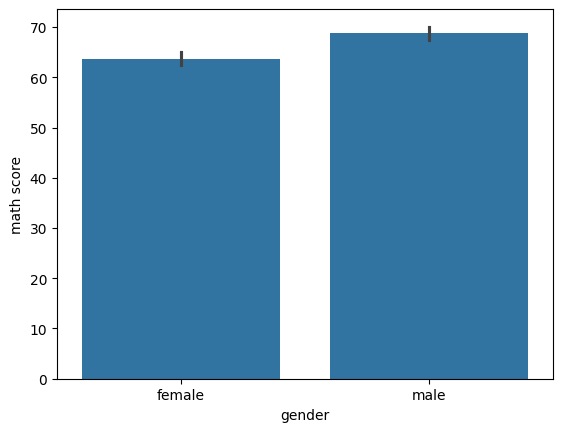

In [8]:
sns.barplot(x='gender', y='math score', data=df)
plt.show()

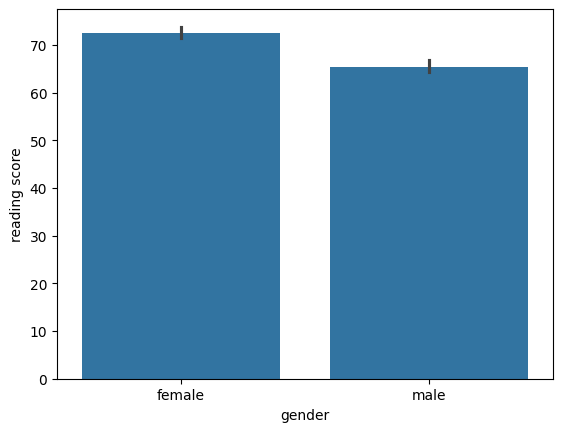

In [9]:
sns.barplot(x='gender', y='reading score', data=df)
plt.show()

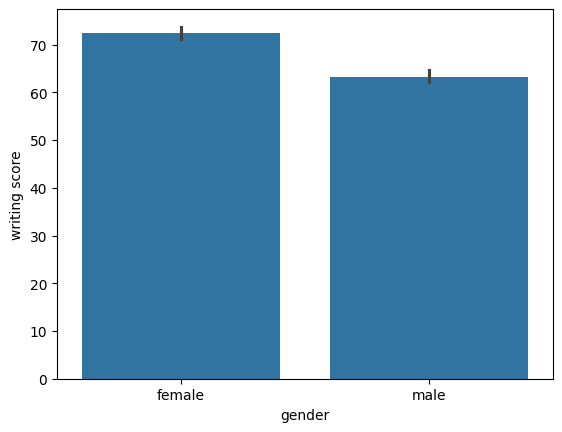

In [10]:
sns.barplot(x='gender', y='writing score', data=df)
plt.show()

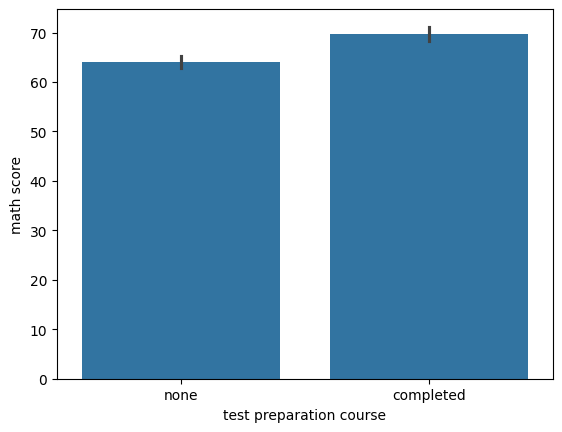

In [11]:
sns.barplot(x='test preparation course', y='math score', data=df)
plt.show()

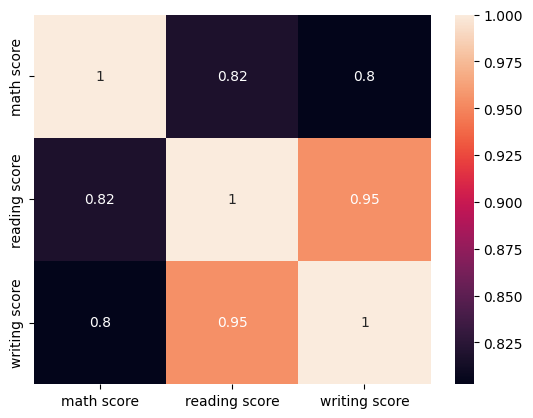

In [12]:
sns.heatmap(df[['math score','reading score','writing score']].corr(), annot=True)
plt.show()

In [13]:
print("Conclusion:")
print("1. Students with test preparation scored better.")
print("2. Female students performed better in reading and writing.")
print("3. Scores are positively related.")
print("4. Multiple factors affect student performance.")

Conclusion:
1. Students with test preparation scored better.
2. Female students performed better in reading and writing.
3. Scores are positively related.
4. Multiple factors affect student performance.


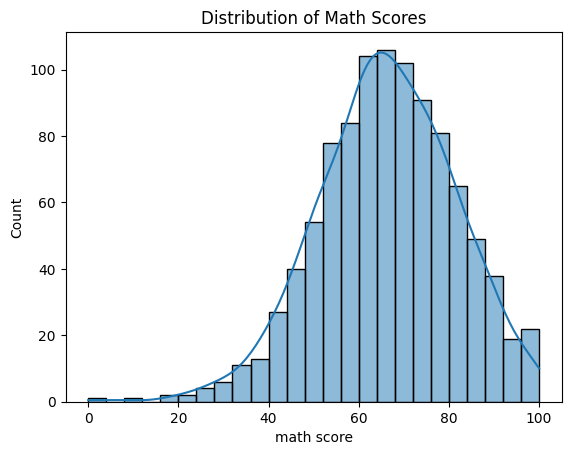

In [14]:
sns.histplot(df['math score'], kde=True)
plt.title("Distribution of Math Scores")
plt.show()

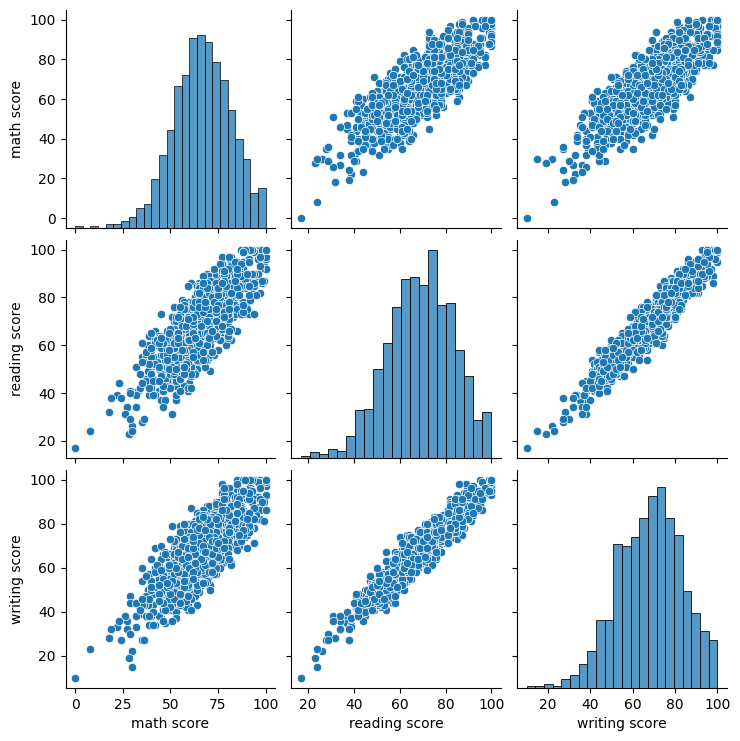

In [15]:
sns.pairplot(df[['math score','reading score','writing score']])
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [17]:
le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])
df['race/ethnicity'] = le.fit_transform(df['race/ethnicity'])
df['parental level of education'] = le.fit_transform(df['parental level of education'])
df['lunch'] = le.fit_transform(df['lunch'])
df['test preparation course'] = le.fit_transform(df['test preparation course'])

In [18]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,1,1,1,1,72,72,74
1,0,2,4,1,0,69,90,88
2,0,1,3,1,1,90,95,93
3,1,0,0,0,1,47,57,44
4,1,2,4,1,1,76,78,75


In [19]:
X = df[['gender','race/ethnicity','parental level of education','lunch','test preparation course','reading score','writing score']]
y = df['math score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [20]:
y_pred = model.predict(X_test)

error = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", error)

Mean Absolute Error: 4.130145078004054


In [21]:
new_student = [[0, 2, 3, 1, 1, 80, 85]]

prediction = model.predict(new_student)

print("Predicted Math Score:", prediction[0])

Predicted Math Score: 76.27741305402982


C:\Users\sp072\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

In [23]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "KNN": KNeighborsRegressor()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    score = r2_score(y_test, pred)
    print(name, "Accuracy:", round(score * 100, 2), "%")

Linear Regression Accuracy: 88.38 %
Random Forest Accuracy: 84.97 %
Decision Tree Accuracy: 74.76 %
KNN Accuracy: 66.2 %


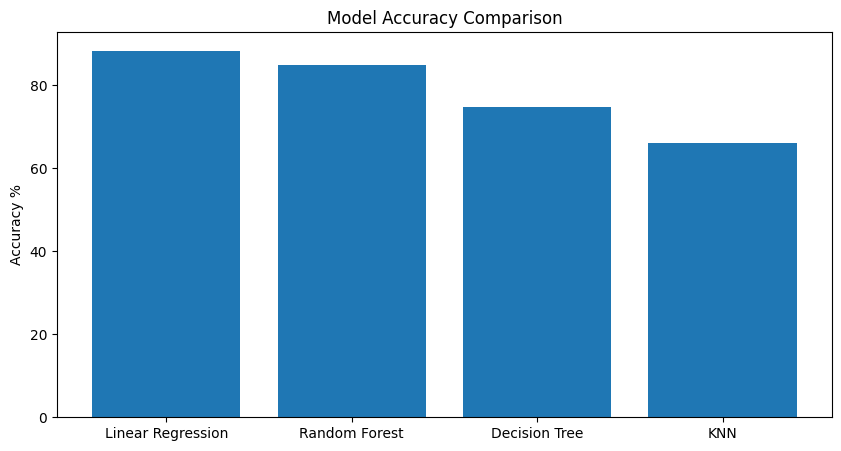

In [24]:
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Random Forest', 'Decision Tree', 'KNN']
scores = [88.38, 84.97, 74.76, 66.20]

plt.figure(figsize=(10,5))
plt.bar(models, scores)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy %")
plt.show()